# Usage Example of Pyspectrum
pyspectrum is a package that helps with handeling spectra.\
The package includes spectrum realization via xarray and other standard python tools.\
In here, the basic use of PySpectrum is presented.\
We'll load a spectrum and calibrate it and normlized it.

In [1]:
from pyspectrum import Spectrum, Calibration
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Loading a new spectrum
The spectrum is of Eu152, and there was not calibration yet.

In [2]:
path = '../Library/152Eu_calsource_10cm_85ks.txt'
spectrum = pd.read_csv(path, names=['counts'])
spectrum['channel'] = spectrum.index 
spectrum = Spectrum.from_dataframe(spectrum)

Text(0, 0.5, 'Counts')

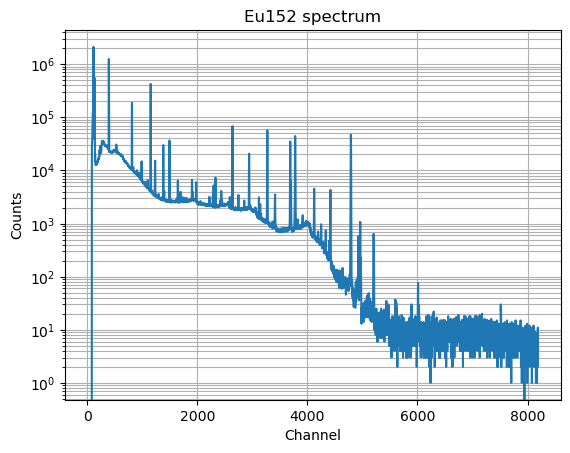

In [3]:
spectrum.plot(yscale='log')
plt.grid(True, which='both')
plt.title('Eu152 spectrum')
plt.xlabel('Channel')
plt.ylabel('Counts')

## calibration generator

choose the obvious photobpeaks in the spectrum

In [4]:
domains = [(383, 403), (1140,1165), (1485, 1505), (2627, 2650), (3260,3285), (4770, 4810)]
energies = [121.78, 344.28, 443.96, 778.9, 964.08, 1408]

find the calibration

In [5]:
calib = Calibration(xr.DataArray(spectrum.counts, {'channel':spectrum.channels}), energies, domains)
energy_calibration, resolution_calibration = calib.generate_calibration(1, p0=[0, 0.02,0])

In [6]:
peaks_center_ch, peaks_fwhm_ch = calib.estimate_fwhm_and_center()
fwhm_val = (energy_calibration(peaks_center_ch+peaks_fwhm_ch/2) - energy_calibration(peaks_center_ch-peaks_fwhm_ch/2))

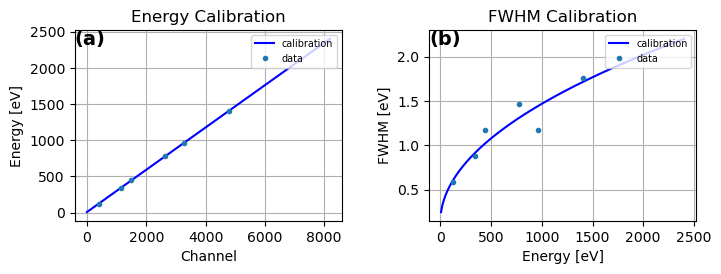

In [7]:
# === Create Side-by-Side Figure ===
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(7.1, 2.625), constrained_layout=True, gridspec_kw={'wspace': 0.1} )

# === Left plot: Energy Calibration ===
ax1.plot(spectrum.channels, energy_calibration(spectrum.channels), 'b-', label='calibration')
ax1.plot(peaks_center_ch, energy_calibration(peaks_center_ch), marker='.', ls='', label='data')
ax1.set_xlabel('Channel')
ax1.set_ylabel('Energy [eV]')
ax1.set_title('Energy Calibration')
ax1.grid(which='both')
ax1.legend(fontsize='x-small', loc='upper right', frameon=True)
ax1.text(0, 1, '(a)', transform=ax1.transAxes, fontsize=14, fontweight='bold', va='top')

# === Right plot: FWHM  ===

ax2.plot(energy_calibration(spectrum.channels), resolution_calibration(energy_calibration(spectrum.channels)), 'b-', label='calibration')
ax2.plot(energies, fwhm_val, marker='.', ls='', label='data')
ax2.set_xlabel('Energy [eV]')
ax2.set_ylabel('FWHM [eV]')
ax2.set_title('FWHM Calibration')
ax2.grid(which='both')
ax2.legend(fontsize='x-small', loc='upper right', frameon=True)
ax2.text(0, 1.0, '(b)', transform=ax2.transAxes, fontsize=14, fontweight='bold', va='top')

# === Show ===
plt.show()


Now we can calibrate calibration 

In [8]:
spectrum.calibrate_energy(energy_calibration)
spectrum.calibrate_fwhm(resolution_calibration)

Text(0, 0.5, 'Counts')

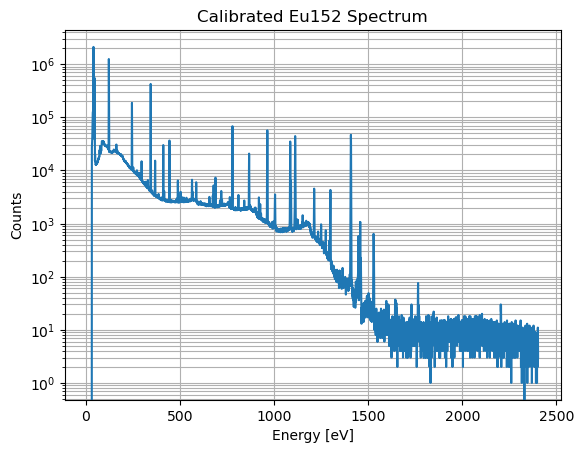

In [9]:
spectrum.plot(yscale='log')
plt.grid(True, which='both')
plt.title('Calibrated Eu152 Spectrum')
plt.xlabel('Energy [eV]')
plt.ylabel('Counts')

# Operations

Note that the spectrum object can be treated as an xarray (mostly)\
This means it can be normlized and operated easly

Text(0, 0.5, 'Counts rate [cps]')

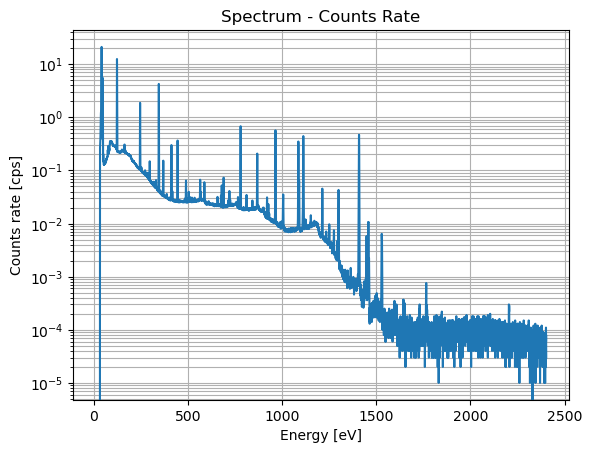

In [10]:
measurement_time = 1e5
(spectrum/measurement_time).plot(yscale='log')
plt.grid(True, which='both')
plt.title('Spectrum - Counts Rate')
plt.xlabel('Energy [eV]')
plt.ylabel('Counts rate [cps]')

## findPeaks
An example how to find domains in which the counts are above snr

In [18]:
from pyspectrum.peak_identification import Convolution, FindPeaksDomain,FindPeaksCenters, gaussian_2_dev
from pyspectrum.peak_fitting import GaussianWithBGFitting

In [12]:
# The find peaks method (maybe it should be self contained)
convolution = Convolution(spectrum.fwhm_calibration, gaussian_2_dev)
find_peaks = FindPeaksDomain(spectrum, convolution, n_sigma_threshold=4)
peaks_domain = find_peaks.find_domains_above_snr()

In [13]:
spectrum.energy_calibration(peaks_domain)[0:5]

array([[26.51049245, 50.20473139],
       [71.26627711, 76.82418501],
       [78.87183528, 80.62696409],
       [80.91948556, 82.3820929 ],
       [82.96713584, 85.89235052]])

The peaks center can be found using the Mariscotti method

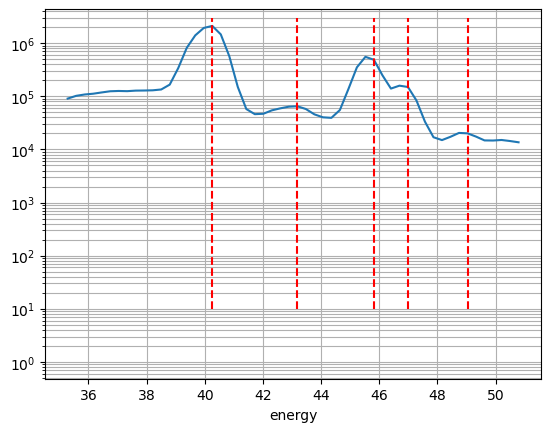

In [14]:
spectrum.xr_spectrum().sel(energy=slice(35,51)).plot(yscale='log')
minimal_statistical_accuracy = 0.05
f_local = spectrum.fwhm_calibration(25)
resolution = f_local / (2 * np.sqrt(2 * np.log(2)))
minimal_counts_in_peak = 1 / minimal_statistical_accuracy ** 2
minimal_prominence = minimal_counts_in_peak / (0.761438079 * np.sqrt(2 * np.pi) * resolution)
fp = FindPeaksCenters(spectrum.xr_spectrum().sel(energy=slice(24,51)), resolution/4, minimal_prominence)
for c in fp():
    plt.vlines(ymax=3e6, ymin=10, x=c, color='red', ls='--')
plt.grid(True, which='both')

Spectrum can be analayzed easily, this is exampled here by fitting all of the peaks

C:\Users\ahiaa\anaconda3\Lib\site-packages\scipy\optimize\_minpack_py.py:1010: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


(1000.0, 2000000.0)

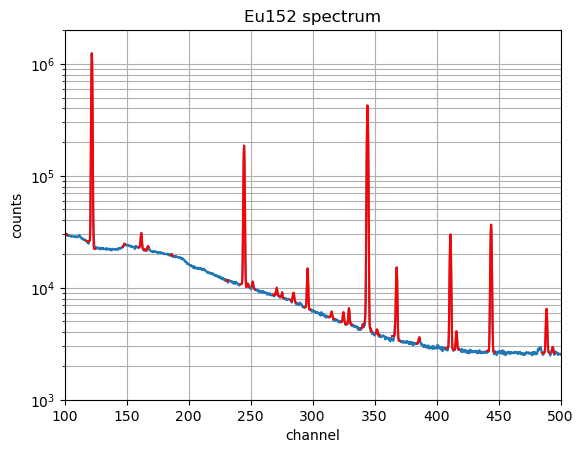

In [15]:
# note that using plot_all_peaks shows all the peaks in
plt.axes(yscale='log')
spectrum.plot_all_peaks(n_sigma_threshold=4, minimal_statistical_accuracy=0.1, smoothing_factor=4)
plt.grid(True, which='both')
plt.title('Eu152 spectrum')
plt.xlabel('channel')
plt.ylabel('counts')
plt.xlim([100, 500])
plt.ylim([1e3, 2e6])

in here the fitting is saved in x and y

In [16]:
x, y = spectrum.fit_peaks(n_sigma_threshold=4, minimal_statistical_accuracy=0.1)

C:\Users\ahiaa\anaconda3\Lib\site-packages\scipy\optimize\_minpack_py.py:1010: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


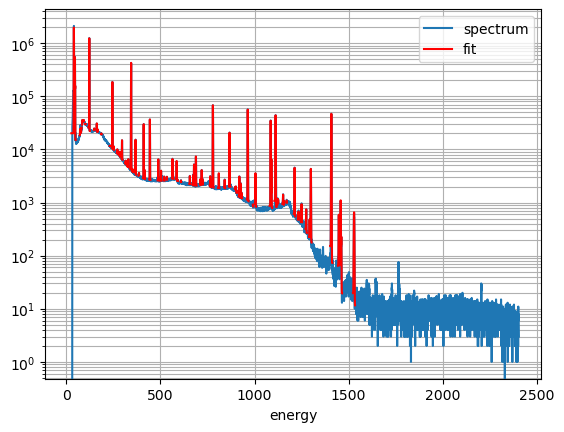

In [19]:
spectrum.xr_spectrum().plot(yscale='log')

for i, peak in enumerate(x):
    energy_domain = spectrum.energy_calibration(np.arange(y[i][0], y[i][1], 1))
    GaussianWithBGFitting.plot_fit(energy_domain, peak)
plt.grid(which='both')
plt.legend(['spectrum', 'fit'])